### This code provides supports for results on Analyses for Aging-Specific Services, including those in Main Text section 2.5 and SI section A.9.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import statsmodels.api as sm

d:\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
f_old_svc=['Nursing and Residential Care Facilities','Services for the Elderly and Persons with Disabilities','Home Health Care Services','Personal Care Services']

usecol=['census_block_group','social_child_type','demand_ratios','demand_met_in_local']

df_list=[]

###data source 1: childtype accratio
for ctype in f_old_svc:
    df_list.append(pd.read_csv('data/A for aging specific services/sumAll_'+ctype+'.csv',usecols=usecol))
df_f_old=pd.concat(df_list)
###data source 1: childtype accratio

###data source 2: census data
df_census_all=pd.read_csv('data/census/all_census_data_with_location.csv')
###data source 2: census data

df_census_all['census_block_group']=df_census_all['census_block_group'].astype(str)

df_age=df_census_all[['census_block_group','percent_above_65']]
df_age['52age']=df_age.apply(lambda x: 0 if x['percent_above_65']<0.2 else 0.5, axis=1)
df_age['52age']=df_age.apply(lambda x: 1 if x['percent_above_65']>0.5 else x['52age'], axis=1)

df_f_old['census_block_group']=df_f_old['census_block_group'].astype(str)

df_f_old=pd.merge(df_f_old,df_age,on='census_block_group',how='left') 

dict_state={'1': 'AL', '2': 'AK', '4': 'AZ', '5': 'AR', '6': 'CA', '8': 'CO', '9': 'CT', '10': 'DE', '11': 'DC', '12': 'FL', '13': 'GA', '15': 'HI', '16': 'ID',
            '17': 'IL', '18': 'IN', '19': 'IA', '20': 'KS', '21': 'KY', '22': 'LA', '23': 'ME', '24': 'MD', '25': 'MA', '26': 'MI', '27': 'MN', '28': 'MS', '29': 'MO',
            '30': 'MT', '31': 'NE', '32': 'NV', '33': 'NH', '34': 'NJ', '35': 'NM', '36': 'NY', '37': 'NC', '38': 'ND', '39': 'OH', '40': 'OK', '41': 'OR', '42': 'PA', 
            '44': 'RI', '45': 'SC', '46': 'SD', '47': 'TN', '48': 'TX', '49': 'UT', '50': 'VT', '51': 'VA', '53': 'WA', '54': 'WV', '55': 'WI', '56': 'WY', '60': 'AS', 
            '66': 'GU', '69': 'MP', '72': 'PR', '74': 'UM', '78': 'VI'}
df_f_old['state']=df_f_old.apply(lambda x: dict_state[x['census_block_group'][0:2]] if len(x['census_block_group']) ==12 else  dict_state[x['census_block_group'][0:1]] , axis=1  )

C:\Users\Linao\AppData\Local\Temp\ipykernel_30256\2524446011.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['52age']=df_age.apply(lambda x: 0 if x['percent_above_65']<0.2 else 0.5, axis=1)
C:\Users\Linao\AppData\Local\Temp\ipykernel_30256\2524446011.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_age['52age']=df_age.apply(lambda x: 1 if x['percent_above_65']>0.5 else x['52age'], axis=1)


old_num_obs_forNursing and Residential Care Facilities: 1645
old_num_obs_forServices for the Elderly and Persons with Disabilities: 401
old_num_obs_forHome Health Care Services: 676
old_num_obs_forPersonal Care Services: 1356


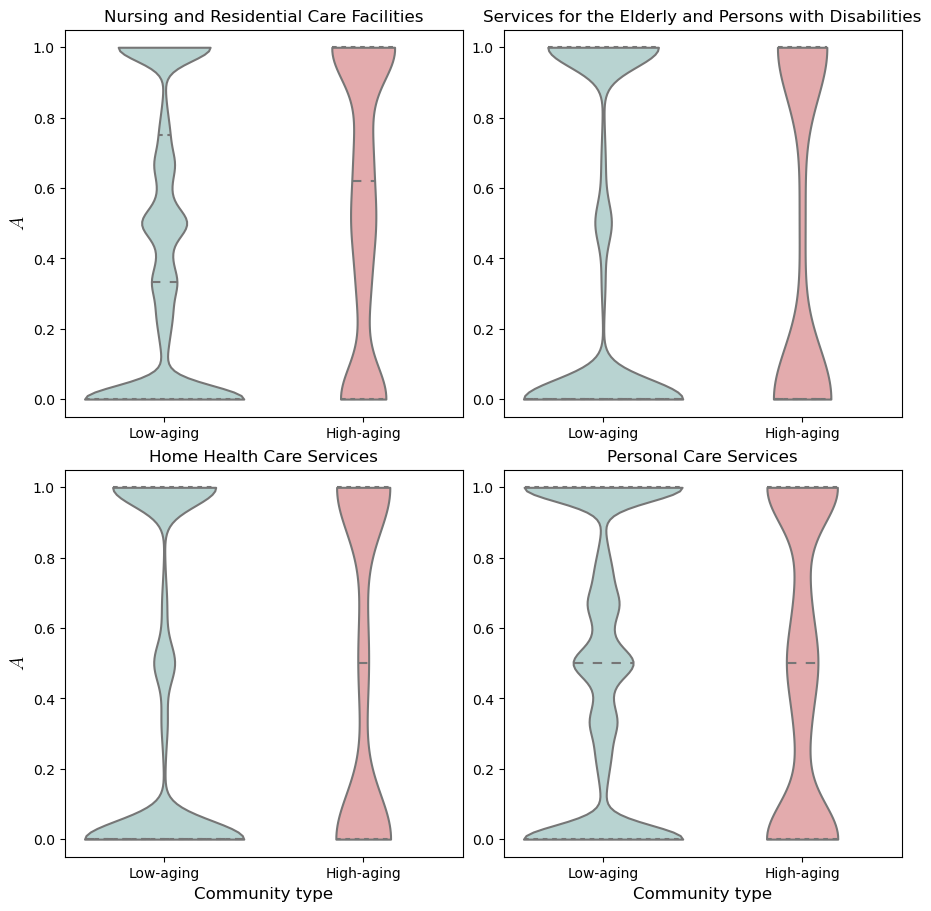

In [3]:
colors={0:'#B3D8D5',1: '#EDA1A4'}

fig, ax=plt.subplots(2,2,constrained_layout=True, figsize=(9, 9))
for i,ctype in enumerate(f_old_svc):
    if i>1:
        k=1
        g=i%2
    else:
        k=0
        g=i

    kk=len( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna() )
    print('old_num_obs_for'+ctype+':', kk )
    sn=sns.violinplot(x='52age',y='demand_met_in_local',ax=ax[k,g],
                        data=df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']!=0.5)].dropna(),cut=0.0,inner="quartiles",palette=colors)
    sn.set_title(ctype)
    if k>0:
        sn.set_xlabel('Community type', fontsize=12)
    else:
        sn.set_xlabel('')
    if g<1:
        sn.set_ylabel(r'$A$', fontsize=14, usetex=True)
    else:
        sn.set_ylabel('')
    ax[k,g].set_xticks([0, 1])  
    ax[k,g].set_xticklabels(['Low-aging', 'High-aging'])

In [4]:
#fig.savefig(r'..\..\..\R1\new results\analyses for elderly\distribution_A_compare.png',dpi=600,bbox_inches='tight')

In [5]:
import numpy as np
from scipy.stats import ttest_ind

dic_pv={}

for i,ctype in enumerate(f_old_svc):
    print(ctype)
    group1 = df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna()['demand_met_in_local']
    group2 = df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==0)].dropna()['demand_met_in_local']

    # Welch t 检验
    t_stat, p_value = ttest_ind(group1, group2, equal_var=False)

    
    print(f"t value: {t_stat}")
    print(f"P value: {p_value}")

    if p_value<0.001:
        dic_pv[ctype]='***'
    elif p_value<0.01:
        dic_pv[ctype]='**'
    elif p_value<0.05:
        dic_pv[ctype]='*'
    else:
        dic_pv[ctype]='NS(P_value='+ str(p_value)[:4]+')'

    alpha = 0.001  
    if p_value < alpha:
        
        if np.mean(group1) > np.mean(group2):
            print("the mean of high-aging group is larger than that of low-aging group")
        else:
            print("the mean of high-aging group is smaller than that of low-aging group")
    else:
        print("no significant difference between the two groups")
        
    print(ctype)

Nursing and Residential Care Facilities
t value: 15.432080298915348
P value: 2.334102365012386e-50
the mean of high-aging group is larger than that of low-aging group
Nursing and Residential Care Facilities
Services for the Elderly and Persons with Disabilities
t value: 1.8646896144858345
P value: 0.06294443622504414
no significant difference between the two groups
Services for the Elderly and Persons with Disabilities
Home Health Care Services
t value: 4.921150508559833
P value: 1.0765895408107206e-06
the mean of high-aging group is larger than that of low-aging group
Home Health Care Services
Personal Care Services
t value: -0.14930279519688744
P value: 0.8813364850090968
no significant difference between the two groups
Personal Care Services


In [6]:

for i,ctype in enumerate(f_old_svc):
    print ( ctype , len ( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['demand_met_in_local']==0)] ), 
           len ( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna(subset=['demand_met_in_local'], axis=0) ) )



Nursing and Residential Care Facilities 448 1645
Services for the Elderly and Persons with Disabilities 202 401
Home Health Care Services 301 676
Personal Care Services 489 1356


In [7]:
sum_state=[]
for ctype in f_old_svc:
    for state in df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna()['state'].unique():
        sum_state.append( (ctype, state, 
                           len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)].dropna() ),
                            len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)&(df_f_old['demand_met_in_local']==0)] ) ,
                            len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)&(df_f_old['demand_met_in_local']==0)] ) / len(df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)&(df_f_old['state']==state)].dropna() )
                             ) )

df_sum_state=pd.DataFrame(sum_state,columns=['ctype','state','num_old','num_old_zero_A','ratio_old_zero_A'])


In [8]:
df_sum_state

,ctype,state,num_old,num_old_zero_A,ratio_old_zero_A
0,Nursing and Residential Care Facilities,AL,7,3,0.428571
1,Nursing and Residential Care Facilities,AZ,196,81,0.413265
2,Nursing and Residential Care Facilities,AR,11,2,0.181818
3,Nursing and Residential Care Facilities,CA,158,43,0.272152
4,Nursing and Residential Care Facilities,CO,12,4,0.333333
...,...,...,...,...,...
160,Personal Care Services,VA,15,6,0.400000
161,Personal Care Services,WA,13,5,0.384615
162,Personal Care Services,WV,1,0,0.000000
163,Personal Care Services,WI,5,2,0.400000


In [9]:
dic_pv

{'Nursing and Residential Care Facilities': '***',
 'Services for the Elderly and Persons with Disabilities': 'NS(P_value=0.06)',
 'Home Health Care Services': '***',
 'Personal Care Services': 'NS(P_value=0.88)'}

old_num_obs_forNursing and Residential Care Facilities: 1645
old_num_obs_forServices for the Elderly and Persons with Disabilities: 401
old_num_obs_forHome Health Care Services: 676
old_num_obs_forPersonal Care Services: 1356


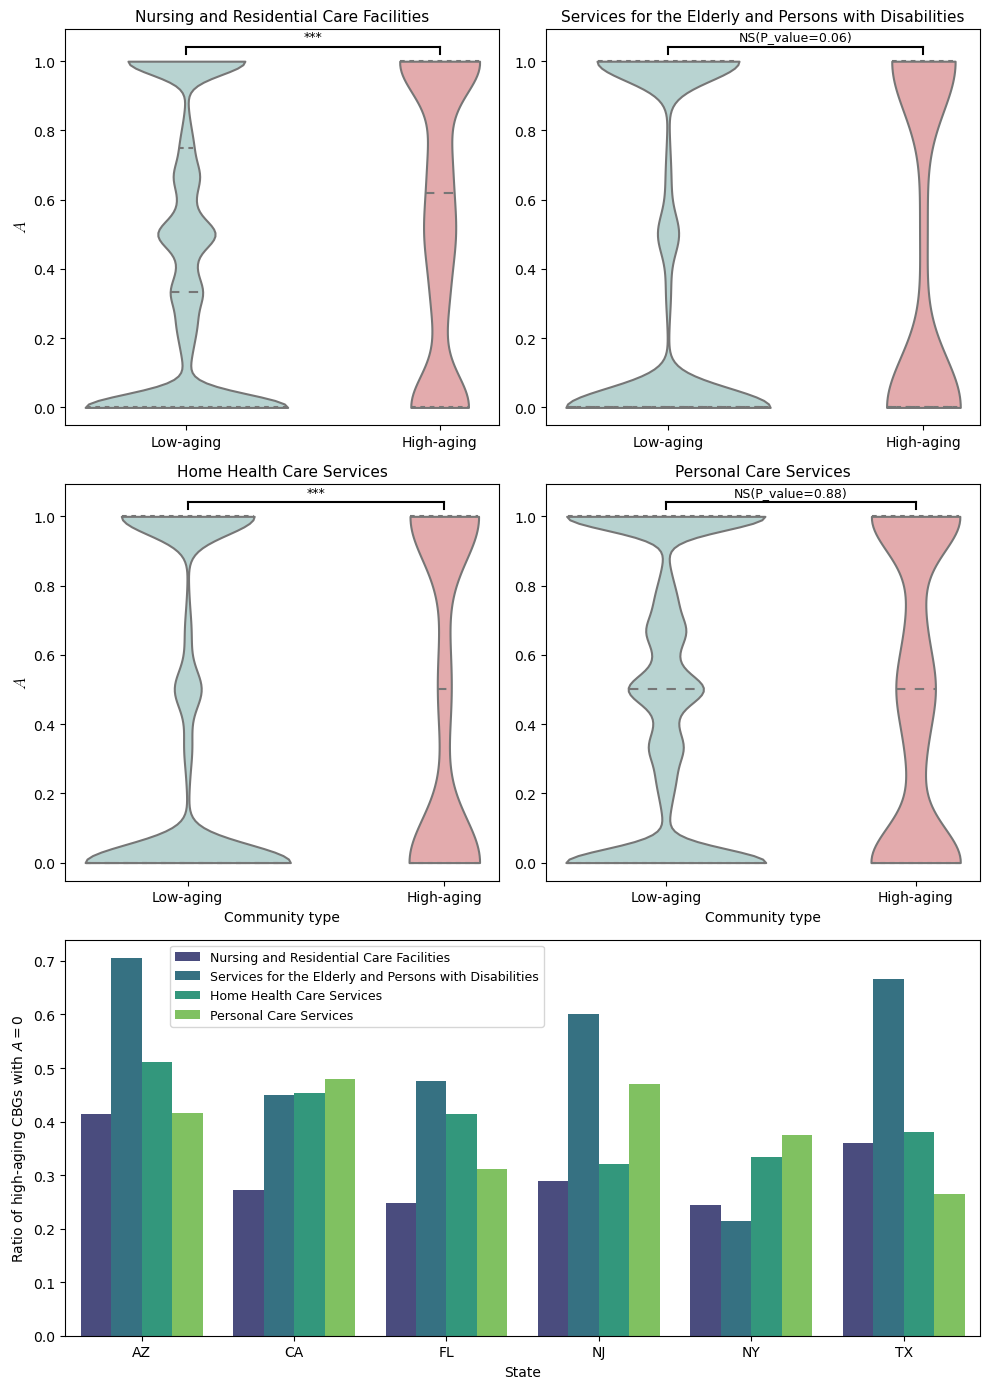

In [10]:


figg=plt.figure(figsize=(10,14))

fig=gridspec.GridSpec(3,2)

#ax0=plt.subplot(fig[0,:3])

ax1=plt.subplot(fig[2,:2])

colors={0:'#B3D8D5',1: '#EDA1A4'}


for i,ctype in enumerate(f_old_svc):
    if i>1:
        k=1
        g=i%2
    else:
        k=0
        g=i

    kk=len( df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']==1)].dropna() )
    print('old_num_obs_for'+ctype+':', kk )
    sn=sns.violinplot(x='52age',y='demand_met_in_local',ax=plt.subplot(fig[k,g]),
                        data=df_f_old[(df_f_old['social_child_type']==ctype)&(df_f_old['52age']!=0.5)].dropna(),cut=0.0,inner="quartiles",palette=colors)
    sn.set_title(ctype,fontsize=11)
    if k>0:
        sn.set_xlabel('Community type', fontsize=10)
    else:
        sn.set_xlabel('')
    if g<1:
        sn.set_ylabel(r'$A$', fontsize=12, usetex=True)
    else:
        sn.set_ylabel('')
    sn.set_xticks([0, 1])  
    sn.set_xticklabels(['Low-aging', 'High-aging'])

    loc_dict={}
    for j, violin in enumerate(sn.collections):
        #if j%2==0:
        vertices = violin.get_paths()[0].vertices
        top_position_y = vertices[:, 1].max()
        
        lowlist=[]
        for v in vertices:
            if v[1]==0:
                lowlist.append(v[0])
        top_position_x = (max(lowlist)+min(lowlist) )/2
        loc_dict[j]=(top_position_x,top_position_y)

        #print(j)
    t=0.02
    x1=loc_dict[0][0]
    y1=loc_dict[0][1]+t
    x2=loc_dict[1][0]
  

    sn.plot([x1,x1],[y1,y1+t],color='black')
    sn.plot([x2,x2],[y1,y1+t],color='black')
    sn.plot([x2,x1],[y1+t,y1+t],color='black')

    sn.text((x1+x2)/2,y1+2*t,dic_pv[ctype],ha='center',fontsize=9)


feasible_state=['AZ','CA','FL','NJ','NY','TX']
sn2=sns.barplot(x='state', y='ratio_old_zero_A',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax1)
sn2.set_ylabel(r'Ratio of high-aging CBGs with $A=0$', fontsize=10)
sn2.set_xlabel('State', fontsize=10)

handles, labels = ax1.get_legend_handles_labels()
legend = ax1.legend(
    handles, labels,
    title='',          # 
    loc='upper right', # 
    bbox_to_anchor=(0.53, 1),  # 
    fontsize=9,        #
    frameon=True      #
)

figg.tight_layout()

In [11]:
#figg.savefig(r"D:\main\1_research\P10_Mobility\p10_aging mobility\R1\new results\analyses for elderly\Fig_analyses4elderly.jpg",dpi=600)  


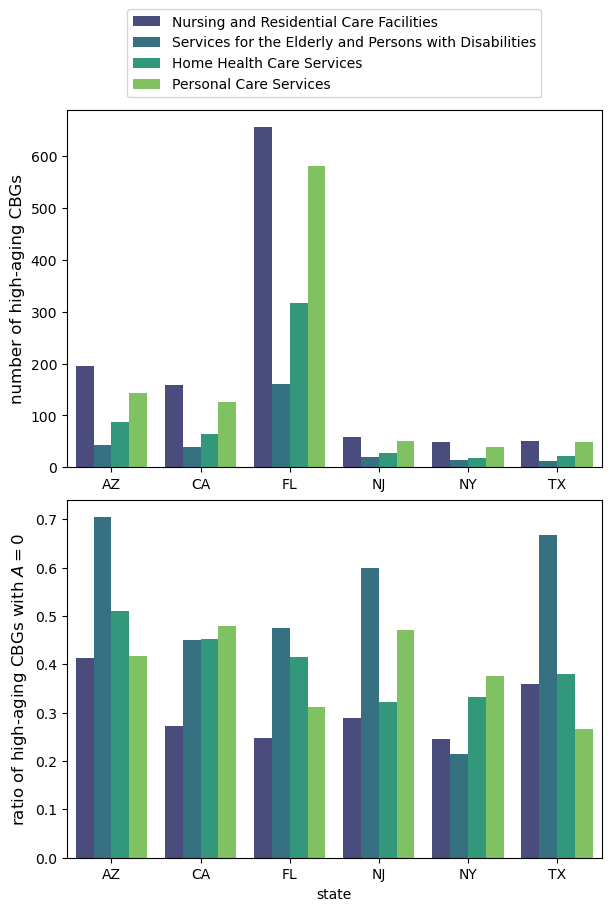

In [12]:
feasible_state=['AZ','CA','FL','NJ','NY','TX']
fig, ax=plt.subplots(2,1,constrained_layout=True, figsize=(6, 9))
sn1=sns.barplot(x='state', y='num_old',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax[0])
sn1.set_xlabel('')
sn1.set_ylabel('number of high-aging CBGs', fontsize=12)
ax[0].legend(title='', loc='upper center', bbox_to_anchor=(0.5, 1.3),  ncol=1)

sn2=sns.barplot(x='state', y='ratio_old_zero_A',hue='ctype', data=df_sum_state[(df_sum_state['state'].isin(feasible_state))], palette="viridis",ax=ax[1])
sn2.set_ylabel(r'ratio of high-aging CBGs with $A=0$', fontsize=12)
ax[1].legend().set_visible(False) 

In [13]:
#fig.savefig(r'..\..\..\R1\new results\analyses for elderly\H_CBG_0_A.png',dpi=600,bbox_inches='tight')